In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../DATA/processed/loan_feature_engineered.csv")

In [3]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120720 entries, 0 to 120719
Data columns (total 62 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   loan_id                   120720 non-null  str    
 1   applicant_id              120720 non-null  str    
 2   customer_name             120720 non-null  str    
 3   gender                    120720 non-null  str    
 4   date_of_birth             120720 non-null  str    
 5   age                       120720 non-null  int64  
 6   marital_status            120720 non-null  str    
 7   education                 120720 non-null  str    
 8   occupation                120720 non-null  str    
 9   employment_type           120720 non-null  str    
 10  employer_name             120720 non-null  str    
 11  years_with_employer       120720 non-null  float64
 12  annual_income             120720 non-null  float64
 13  monthly_income            120720 non-null  float64
 14 

In [4]:
#Default Rate by State
state_default = (
    df.groupby("state")
      .agg(
          Total_Loans=("loan_id", "count"),
          Default_Loans=("default_flag", "sum"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

state_default["Default_Rate"] = (
    state_default["Default_Rate"] * 100
).round(2)

state_default = state_default.sort_values(
    by="Default_Rate",
    ascending=False
)

state_default.head(10)



,state,Total_Loans,Default_Loans,Default_Rate
1,Bihar,4821,485,10.06
14,West Bengal,9668,667,6.90
13,Uttar Pradesh,9669,599,6.20
2,Delhi,9680,572,5.91
10,Rajasthan,9664,509,5.27
9,Punjab,9735,499,5.13
12,Telangana,9647,492,5.10
8,Maharashtra,9478,467,4.93
0,Andhra Pradesh,4832,237,4.90
5,Karnataka,9639,461,4.78


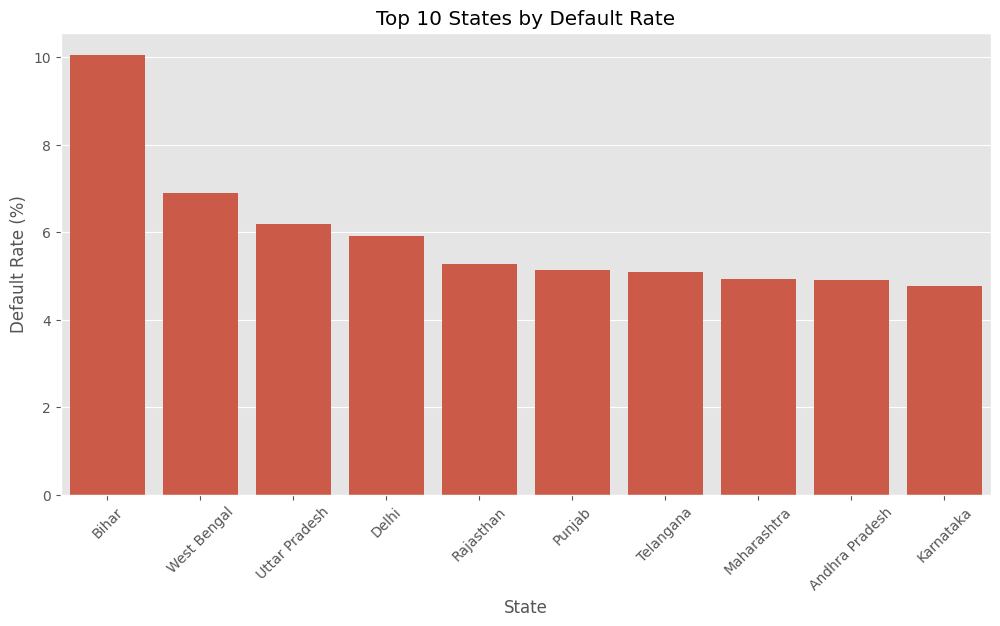

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_default.head(10),
    x="state",
    y="Default_Rate"
)

plt.xticks(rotation=45)
plt.title("Top 10 States by Default Rate")
plt.ylabel("Default Rate (%)")
plt.xlabel("State")

plt.show()

In [6]:

#Default Rate by Region
region_default = (
    df.groupby("region")
      .agg(
          Total_Loans=("loan_id", "count"),
          Default_Loans=("default_flag", "sum"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

region_default["Default_Rate"] = (
    region_default["Default_Rate"] * 100
).round(2)

region_default.sort_values(
    by="Default_Rate",
    ascending=False
)


,region,Total_Loans,Default_Loans,Default_Rate
1,East,14489,1152,7.95
2,North,43612,2395,5.49
3,South,38618,1853,4.80
4,West,19193,840,4.38
0,Central,4808,181,3.76


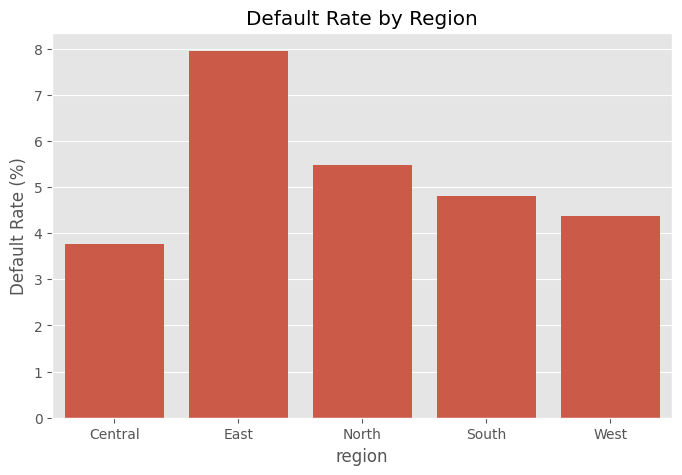

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_default,
    x="region",
    y="Default_Rate"
)

plt.title("Default Rate by Region")
plt.ylabel("Default Rate (%)")
plt.show()

In [8]:
#DEFAULT RATE BY BRANCH
branch_default = (
    df.groupby("branch_name")
      .agg(
          Total_Loans=("loan_id", "count"),
          Default_Loans=("default_flag", "sum"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

branch_default["Default_Rate"] = (
    branch_default["Default_Rate"] * 100
).round(2)

branch_default = branch_default.sort_values(
    by="Default_Rate",
    ascending=False
)

branch_default.head(10)

,branch_name,Total_Loans,Default_Loans,Default_Rate
13,Patna City Branch,4821,485,10.06
3,Howrah City Branch,4837,392,8.10
8,Lucknow City Branch,4748,376,7.92
14,Rohini City Branch,9680,572,5.91
7,Kolkata City Branch,4831,275,5.69
4,Hyderabad Main Branch,4765,255,5.35
6,Jodhpur City Branch,9664,509,5.27
9,Ludhiana Main Branch,9735,499,5.13
12,Nashik City Branch,4719,241,5.11
17,Visakhapatnam Main Branch,4832,237,4.90


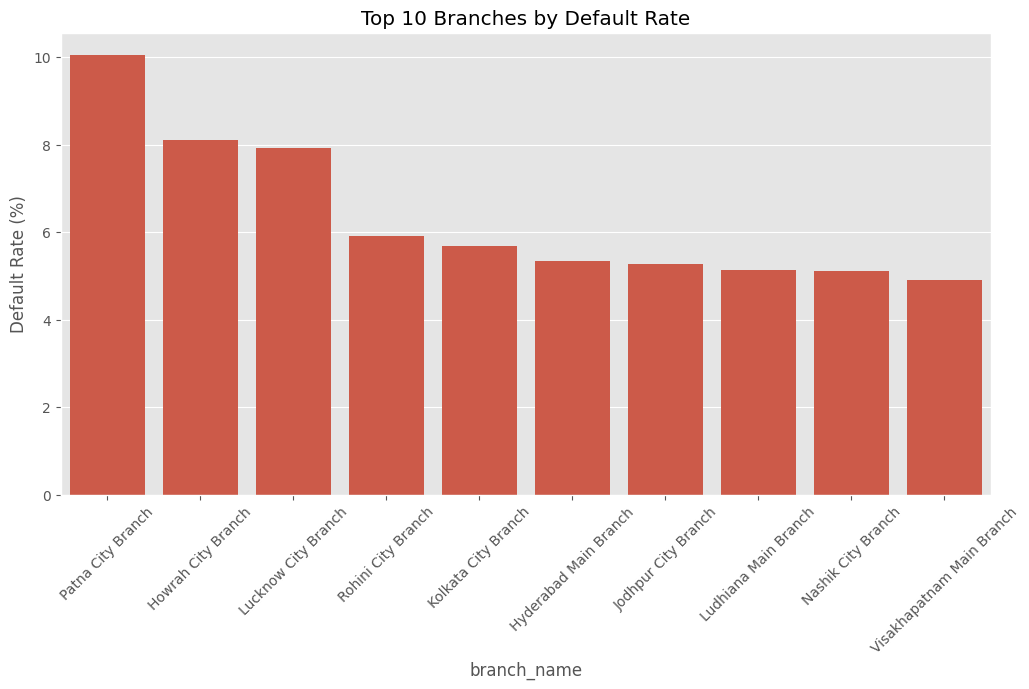

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=branch_default.head(10),
    x="branch_name",
    y="Default_Rate"
)

plt.xticks(rotation=45)
plt.title("Top 10 Branches by Default Rate")
plt.ylabel("Default Rate (%)")

plt.show()

In [11]:
#Credit Score vs Default

In [12]:
credit_analysis = (
    df.groupby("credit_score_category")
      .agg(
          Customers=("loan_id", "count"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

credit_analysis["Default_Rate"] = (
    credit_analysis["Default_Rate"] * 100
).round(2)

credit_analysis

,credit_score_category,Customers,Default_Rate
0,Excellent,10464,2.03
1,Fair,37509,6.21
2,Good,38846,4.49
3,Poor,15462,10.18
4,Very Good,18437,3.04


In [13]:
credit_analysis = (
    df.groupby("credit_score_category")
      .agg(
          Customers=("loan_id", "count"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

credit_analysis["Default_Rate"] = (
    credit_analysis["Default_Rate"] * 100
).round(2)

credit_analysis

,credit_score_category,Customers,Default_Rate
0,Excellent,10464,2.03
1,Fair,37509,6.21
2,Good,38846,4.49
3,Poor,15462,10.18
4,Very Good,18437,3.04


In [14]:
#Debt-to-Income Ratio Analysis

In [15]:
dti_analysis = (
    df.groupby("high_risk_flag")
      .agg(
          Customers=("loan_id", "count"),
          Average_DTI=("debt_to_income_ratio", "mean"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

dti_analysis["Default_Rate"] = (
    dti_analysis["Default_Rate"] * 100
).round(2)

dti_analysis

,high_risk_flag,Customers,Average_DTI,Default_Rate
0,0,120720,0.505958,5.32


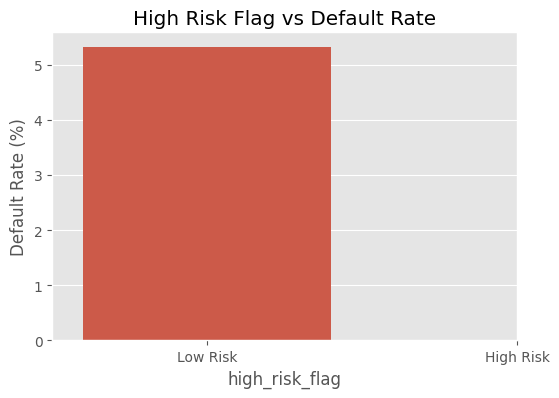

In [16]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=dti_analysis,
    x="high_risk_flag",
    y="Default_Rate"
)

plt.xticks([0, 1], ["Low Risk", "High Risk"])

plt.title("High Risk Flag vs Default Rate")
plt.ylabel("Default Rate (%)")

plt.show()

In [17]:
#Default Rate by Income Category

In [18]:
income_default = (
    df.groupby("income_category")
      .agg(
          Total_Loans=("loan_id", "count"),
          Default_Loans=("default_flag", "sum"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

income_default["Default_Rate"] = (
    income_default["Default_Rate"] * 100
).round(2)

income_default

,income_category,Total_Loans,Default_Loans,Default_Rate
0,High,27140,1164,4.29
1,Low,30238,2551,8.44
2,Medium,33170,1748,5.27
3,Very High,30172,958,3.18


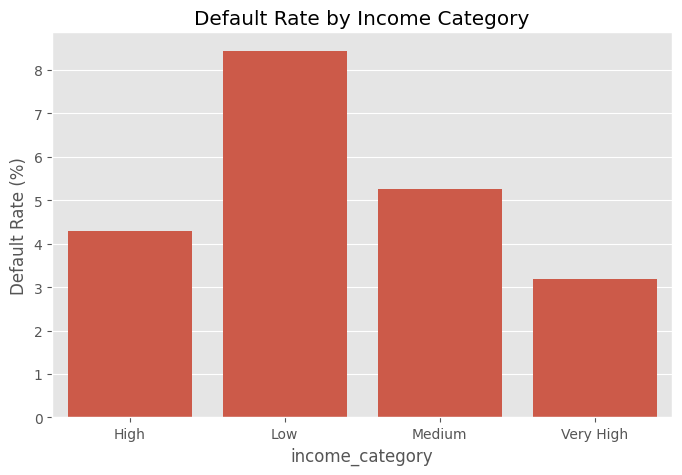

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=income_default,
    x="income_category",
    y="Default_Rate"
)

plt.title("Default Rate by Income Category")
plt.ylabel("Default Rate (%)")
plt.show()

In [20]:
existing_loan_analysis = (
    df.groupby("loan_count_category")
      .agg(
          Customers=("loan_id", "count"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

existing_loan_analysis["Default_Rate"] = (
    existing_loan_analysis["Default_Rate"] * 100
).round(2)

existing_loan_analysis

,loan_count_category,Customers,Default_Rate
0,1-2,68917,5.70
1,3-5,11837,8.83
2,5+,97,11.34
3,No Loan,39869,3.60


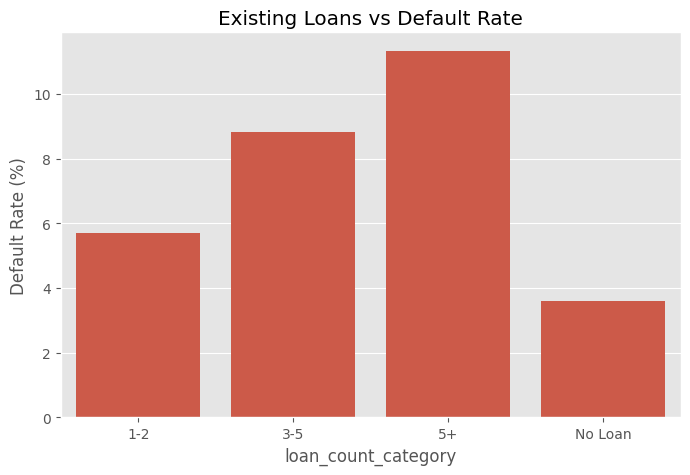

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=existing_loan_analysis,
    x="loan_count_category",
    y="Default_Rate"
)

plt.title("Existing Loans vs Default Rate")
plt.ylabel("Default Rate (%)")
plt.show()

In [22]:
employment_default = (
    df.groupby("employment_type")
      .agg(
          Customers=("loan_id", "count"),
          Default_Rate=("default_flag", "mean"),
          Average_Credit_Score=("credit_score", "mean")
      )
      .reset_index()
)

employment_default["Default_Rate"] = (
    employment_default["Default_Rate"] * 100
).round(2)

employment_default

,employment_type,Customers,Default_Rate,Average_Credit_Score
0,Business Owner,11948,4.83,680.711751
1,Salaried,66505,4.83,679.716758
2,Self-Employed Business,24208,6.42,679.927669
3,Self-Employed Professional,18059,5.99,679.560939


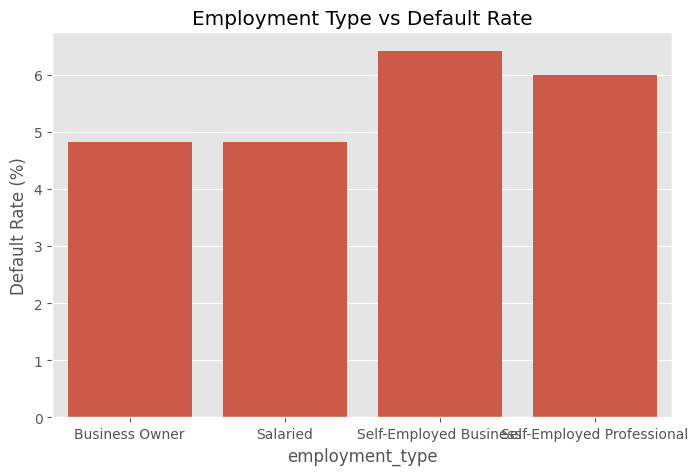

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=employment_default,
    x="employment_type",
    y="Default_Rate"
)

plt.title("Employment Type vs Default Rate")
plt.ylabel("Default Rate (%)")
plt.show()

In [24]:
product_default = (
    df.groupby("loan_product")
      .agg(
          Customers=("loan_id", "count"),
          Default_Rate=("default_flag", "mean")
      )
      .reset_index()
)

product_default["Default_Rate"] = (
    product_default["Default_Rate"] * 100
).round(2)

product_default = product_default.sort_values(
    by="Default_Rate",
    ascending=False
)

product_default

,loan_product,Customers,Default_Rate
3,Personal Loan,48207,5.95
2,Gold Loan,18138,5.58
1,Business Loan,24106,5.15
0,Auto Loan,30269,4.29


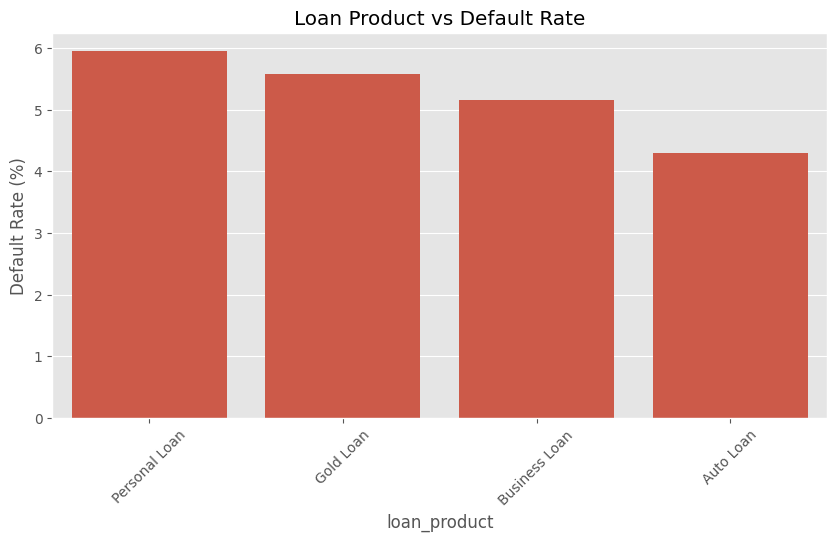

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=product_default,
    x="loan_product",
    y="Default_Rate"
)

plt.xticks(rotation=45)
plt.title("Loan Product vs Default Rate")
plt.ylabel("Default Rate (%)")
plt.show()

In [26]:
#orrelation Analysis

corr = df.select_dtypes(include=["int64", "float64"]).corr()

corr

,age,years_with_employer,annual_income,monthly_income,pincode,loan_amount,sanctioned_amount,disbursed_amount,interest_rate,tenure_months,emi_amount,processing_fee,credit_score,debt_to_income_ratio,existing_loans_count,existing_emi_obligations,collateral_value,default_flag,days_past_due,recovery_amount,payment_history_score,bounce_count,emi_to_income_ratio,loan_utilization,approval_percentage,high_risk_flag
age,1.000000,0.001684,-0.004337,-0.003866,0.000756,-0.000235,-0.000774,-0.000745,-0.002510,-0.001765,0.000424,-0.001692,-0.000067,0.003049,-0.002141,-0.002192,0.004532,0.002762,0.003362,0.000712,-0.003897,0.003264,0.004794,0.002018,-0.003057,NaN
years_with_employer,0.001684,1.000000,-0.004228,-0.002484,0.000545,-0.000222,-0.001701,-0.001712,0.002189,0.006298,-0.002177,-0.001876,0.002599,0.001888,0.002278,0.002608,0.001803,-0.001272,-0.001684,0.000150,0.001992,-0.000204,-0.002393,-0.000984,-0.001987,NaN
annual_income,-0.004337,-0.004228,1.000000,0.332604,-0.001628,0.634230,0.785801,0.785730,-0.000188,-0.000213,0.579308,0.678135,0.003519,-0.223793,0.003828,0.004634,0.326700,-0.073262,-0.065565,0.034588,0.128335,-0.063416,-0.000482,-0.004073,-0.003521,NaN
monthly_income,-0.003866,-0.002484,0.332604,1.000000,-0.000938,0.224061,0.278742,0.278746,0.003174,0.001163,0.203442,0.243011,-0.003028,-0.077968,-0.000230,0.000492,0.119993,-0.023621,-0.020549,0.013944,0.043210,-0.020279,-0.048951,-0.001256,-0.000844,NaN
pincode,0.000756,0.000545,-0.001628,-0.000938,1.000000,-0.003011,-0.002289,-0.002307,-0.001206,-0.001855,-0.001926,-0.000595,0.006381,-0.003502,-0.004303,-0.002328,0.000549,0.002267,0.000811,-0.000986,0.000054,0.003293,-0.002324,-0.001478,0.001237,NaN
loan_amount,-0.000235,-0.000222,0.634230,0.224061,-0.003011,1.000000,0.804555,0.804518,-0.000783,-0.000093,0.595347,0.694053,0.005854,0.010708,0.004041,0.005726,0.336292,-0.035574,-0.032510,0.062012,0.033027,-0.030895,0.219568,-0.000804,-0.346360,NaN
sanctioned_amount,-0.000774,-0.001701,0.785801,0.278742,-0.002289,0.804555,1.000000,0.999891,0.000419,0.000653,0.737061,0.862406,0.003214,0.013788,0.002993,0.004130,0.417355,-0.041135,-0.037691,0.081699,0.038536,-0.036706,0.274596,-0.002839,0.023866,NaN
disbursed_amount,-0.000745,-0.001712,0.785730,0.278746,-0.002307,0.804518,0.999891,1.000000,0.000565,0.000702,0.737084,0.862264,0.003247,0.013859,0.002976,0.004123,0.417268,-0.041194,-0.037756,0.081609,0.038556,-0.036744,0.274712,0.008980,0.023831,NaN
interest_rate,-0.002510,0.002189,-0.000188,0.003174,-0.001206,-0.000783,0.000419,0.000565,1.000000,0.049004,-0.054612,-0.000942,0.002447,-0.045785,0.001134,-0.000043,-0.558014,0.018047,0.016678,0.014140,0.004874,0.016194,-0.077625,0.011502,-0.002465,NaN
tenure_months,-0.001765,0.006298,-0.000213,0.001163,-0.001855,-0.000093,0.000653,0.000702,0.049004,1.000000,-0.440783,0.001441,0.001712,-0.455423,0.000530,-0.000172,-0.000744,-0.042654,-0.038900,-0.036016,0.166725,-0.035220,-0.637803,0.002388,-0.000906,NaN


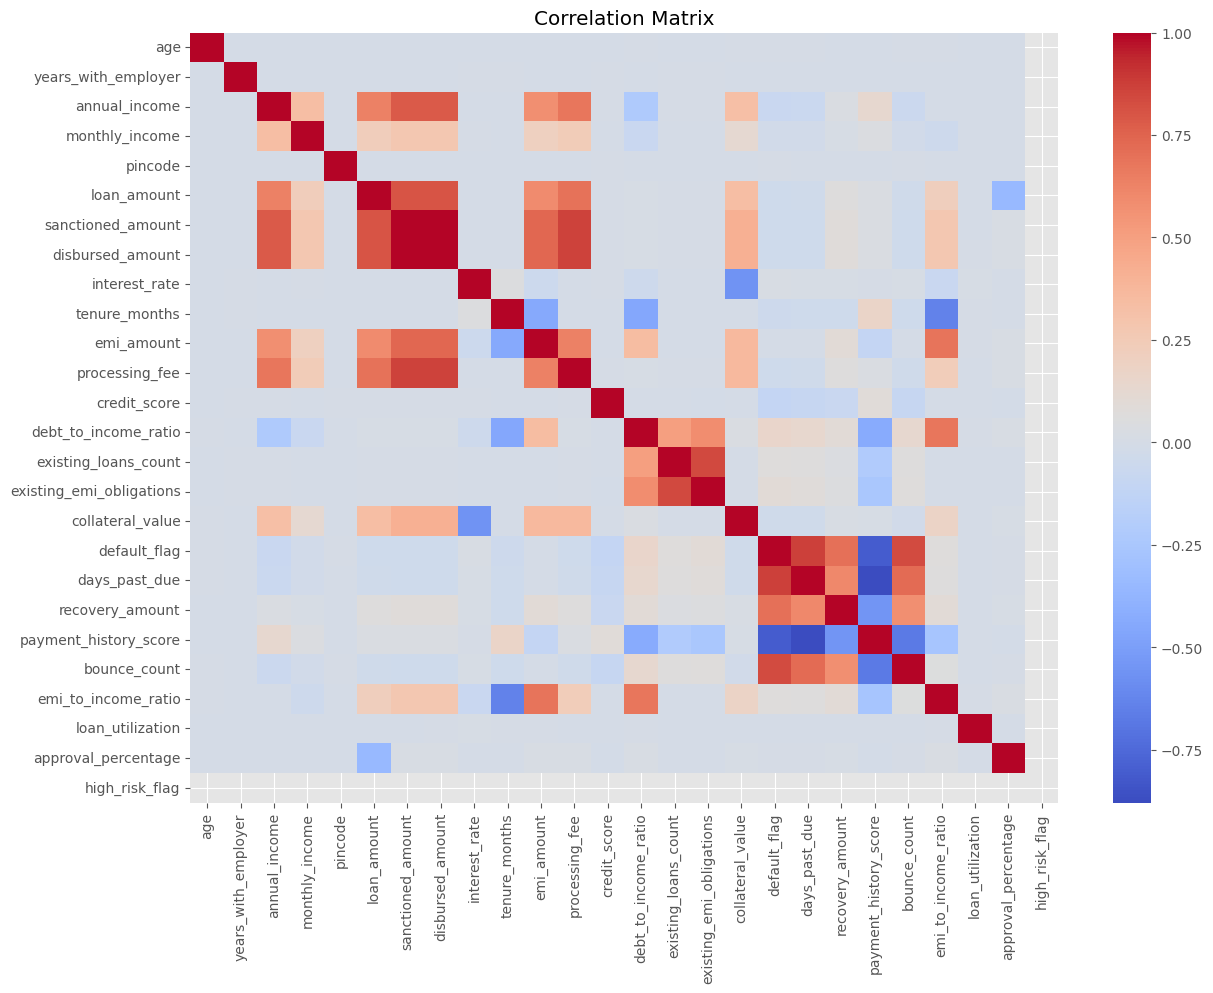

In [28]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()


In [29]:
# High-Risk Customer Profile
high_risk = df[df["high_risk_flag"] == 1]

print("Total High Risk Customers :", len(high_risk))

high_risk[
    [
        "credit_score",
        "annual_income",
        "loan_amount",
        "debt_to_income_ratio"
    ]
].describe()

Total High Risk Customers : 0


,credit_score,annual_income,loan_amount,debt_to_income_ratio
count,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


In [ ]:
#Executive Credit Risk KPIs


print(f"Overall Default Rate      : {df['default_flag'].mean()*100:.2f}%")

print(f"Average Credit Score      : {df['credit_score'].mean():.2f}")

print(f"High Risk Customers       : {df['high_risk_flag'].sum():,}")

print(f"Average DTI Ratio         : {df['debt_to_income_ratio'].mean():.2f}")

print(f"Average Loan Amount       : ₹{df['loan_amount'].mean():,.2f}")